In [1]:
import os
import sys
import json
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import igraph as ig
import leidenalg

In [2]:
start_year = 1998
end_year = 2022
months_per_year = 12
name_str = list(np.load('../data/chimps_names.npy'))
num_chimps = len(name_str)
array_save_name_list = ['full', 'grooming']
graph_type_list = ['learned', 'unlearned', 'binary']

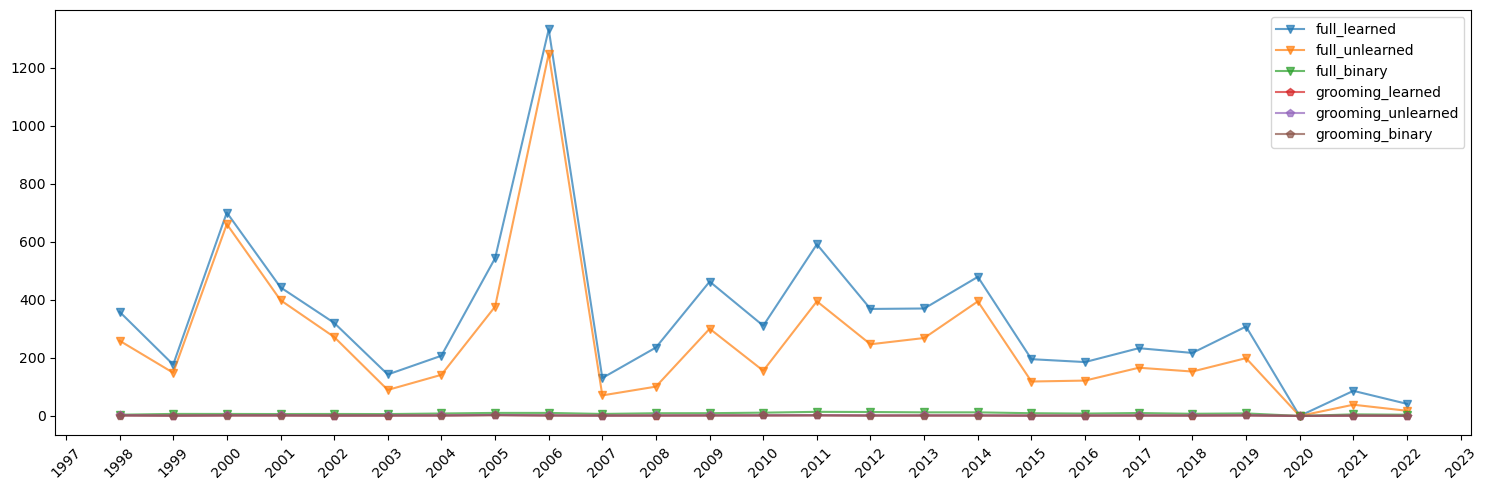

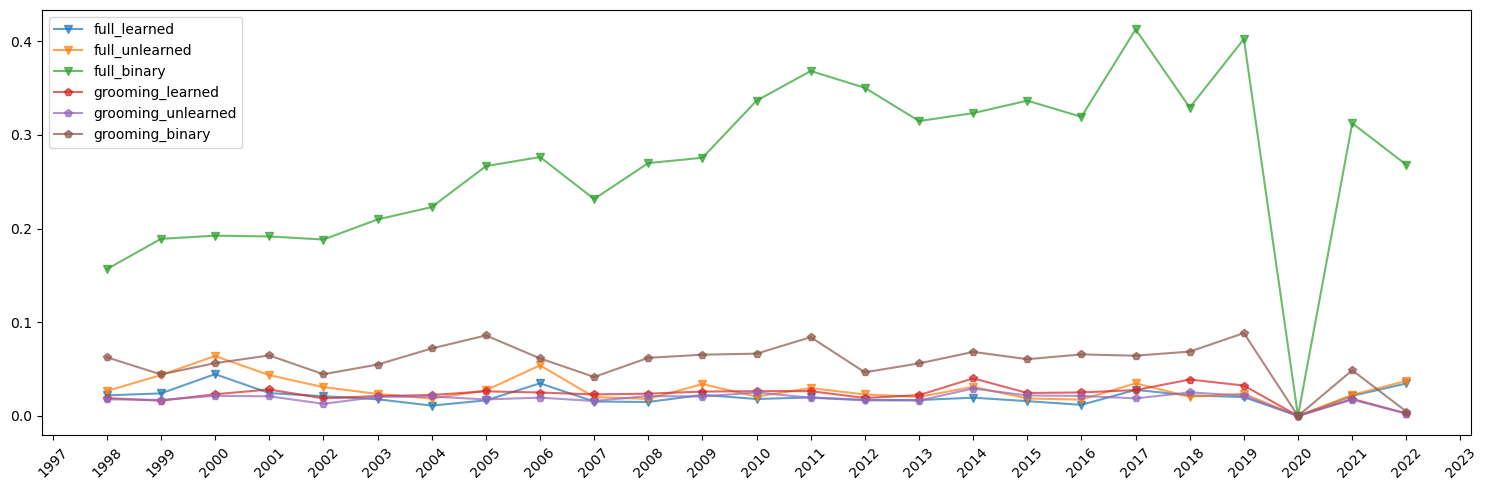

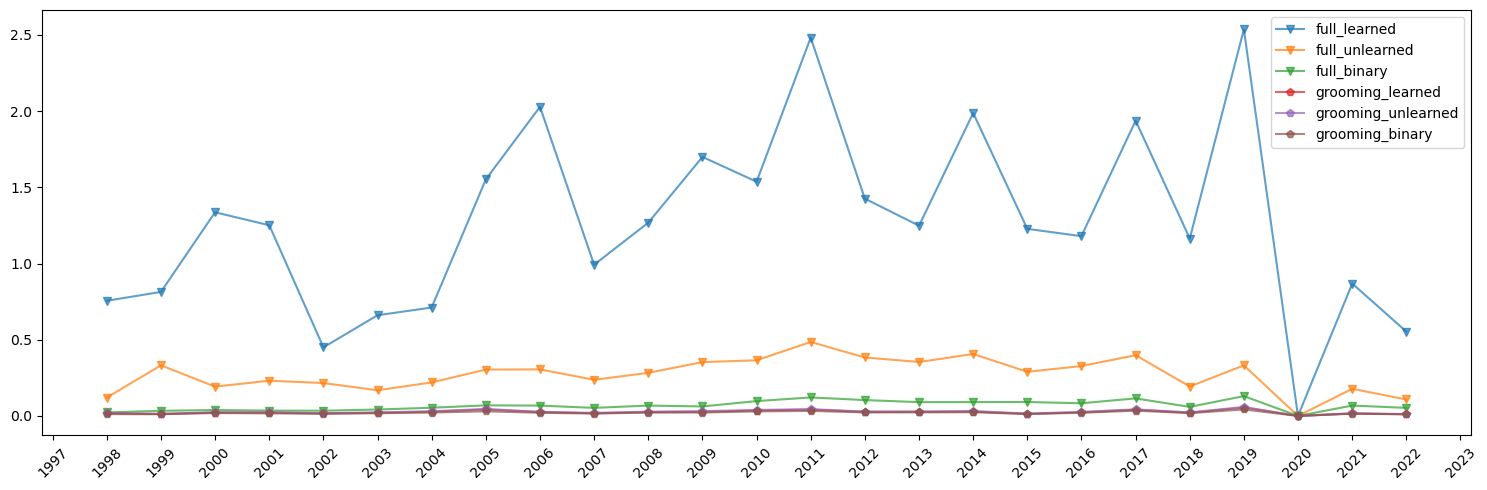

In [4]:
# plotting based on frequencies
marker_dict = {'full':'v', 'grooming':'p'}
dates = pd.date_range(start=str(start_year), end=str(end_year), freq='YS')
plot_types = ['average_weighted_degree', 'average_clustering_coefficient', 'average_close_centrality']
for plot_type in plot_types:
    plt.figure(figsize=(15, 5))
    for array_save_name in array_save_name_list:
        for graph_type in graph_type_list:
            content_of_interest = []
            for year in range(start_year, end_year+1):
                A = np.zeros((num_chimps, num_chimps))
                for month in range(1, months_per_year+1):
                    if graph_type == 'unlearned':
                        curr_A = np.load('../data/unlearned_graphs/'+array_save_name+'_array_'+str(year)+'_'+str(month)+'.npy')
                    else: # learned or binary
                        curr_A = np.load('../data/learned_graphs/'+array_save_name+'_array_'+str(year)+'_'+str(month)+'.npy')
                    A = A + curr_A
                if graph_type == 'binary':
                    A[A > 0] = 1
                G = nx.from_numpy_array(A)
                # remove self loops
                self_loops = list(nx.selfloop_edges(G))
                G.remove_edges_from(self_loops)
                if plot_type == 'average_weighted_degree':
                    content_of_interest.append(np.mean([d for _, d in G.degree(weight='weight')]))
                elif plot_type == 'average_clustering_coefficient':
                    content_of_interest.append(np.mean(list(nx.clustering(G, weight='weight').values())))
                elif plot_type == 'average_close_centrality':
                    g_distance_dict = {(e1, e2): 1 / weight for e1, e2, weight in G.edges(data='weight')}
                    nx.set_edge_attributes(G, g_distance_dict, 'distance')
                    content_of_interest.append(np.mean(list(nx.closeness_centrality(G, distance='distance').values())))
                

        
            # Create a DataFrame for plotting
            df = pd.DataFrame({'Date': dates, 'Value': np.array(content_of_interest)})

            # Create the plot
            label_name = array_save_name+'_'+graph_type
            plt.plot(df['Date'], df['Value'], marker=marker_dict[array_save_name], label=label_name, alpha=0.7)

    # Formatting the x-axis
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()

    # Save and show the plot
    plt.savefig('../analysis_summary_plots/'+plot_type+'.pdf', format='pdf')
    plt.show()

In [7]:
total_num = end_year-start_year+1
for array_save_name in array_save_name_list:
    analysis_name = 'yearly_' + array_save_name
    for graph_type in ['learned', 'unlearned']:
        modularity_val_all = np.zeros(total_num)
        modularity_val_all_binary = np.zeros(total_num)
        modularity_sub_val_all = np.zeros(total_num)
        modularity_sub_val_all_binary = np.zeros(total_num)
        num_communities_all = np.zeros(total_num)
        num_communities_binary_all = np.zeros(total_num)
        community_labels_all = []
        community_labels_binary_all = []
        community_identities_all = np.zeros((total_num, num_chimps))
        community_identities_binary_all = np.zeros((total_num, num_chimps))

        global_ind = 0
        for year in range(start_year, end_year+1):
            A = np.zeros((num_chimps, num_chimps))
            for month in range(1, months_per_year+1):
                if graph_type == 'unlearned':
                    curr_A = np.load('../data/unlearned_graphs/'+array_save_name+'_array_'+str(year)+'_'+str(month)+'.npy')
                else: # learned or binary
                    curr_A = np.load('../data/learned_graphs/'+array_save_name+'_array_'+str(year)+'_'+str(month)+'.npy')
                A = A + curr_A
            if graph_type == 'binary':
                A[A > 0] = 1
            G = nx.from_numpy_array(A)
            # remove self loops
            self_loops = list(nx.selfloop_edges(G))
            G.remove_edges_from(self_loops)

            # Ensure all weights are floats
            try:
                for _, _, data in G.edges(data=True):
                    data['weight'] = float(data['weight'])

                # Extract edges and weights from the NetworkX graph
                edges = [(u, v) for u, v, d in G.edges(data=True)]
                weights = [float(d['weight']) for u, v, d in G.edges(data=True)]

                # Create an igraph Graph from the edges
                ig_G = ig.Graph(edges=edges)

                # Assign weights
                ig_G.es['weight'] = weights

                best_partition = None
                best_modularity = -10000
                for _ in range(20): # run 20 times and take the best partition
                    # Apply the Leiden algorithm using the specified weights
                    partition = leidenalg.find_partition(ig_G, partition_type=leidenalg.RBConfigurationVertexPartition, weights='weight')

                    # modularity
                    modularity_val = partition.modularity
                    if modularity_val > best_modularity:
                        best_modularity = modularity_val
                        best_partition = partition
                # Get the communities
                communities = best_partition.membership
                # modularity
                modularity_val = best_modularity
                isolated_nodes = list(nx.isolates(G))
                community_identities = -np.ones(num_chimps)
                community_identities[:len(communities)] = communities.copy()
                for isolated_node in isolated_nodes:
                    community_identities[isolated_node] = -1
                community_identities = community_identities.astype(int)
                # for binary graphs
                best_partition = None
                best_modularity = -np.inf
                for _ in range(20): # run 20 times and take the best partition
                    # Apply the Leiden algorithm using the specified weights
                    partition = leidenalg.find_partition(ig_G, partition_type=leidenalg.RBConfigurationVertexPartition, weights=None)

                    # modularity
                    modularity_val_binary = partition.modularity
                    if modularity_val_binary > best_modularity:
                        best_modularity = modularity_val_binary
                        best_partition = partition
                # Get the communities
                communities = best_partition.membership
                # modularity
                modularity_val_binary = best_modularity
                community_identities_binary = -np.ones(num_chimps)
                community_identities_binary[:len(communities)] = communities.copy()
                for isolated_node in isolated_nodes:
                    community_identities_binary[isolated_node] = -1
                community_identities_binary = community_identities_binary.astype(int)

                num_communities = community_identities.max() + 1
                num_communities_binary = community_identities_binary.max() + 1
                # Create a dictionary to hold the community label for each node
                community_labels = {i: int(community) for i, community in enumerate(community_identities)}
                community_labels_binary = {i: int(community) for i, community in enumerate(community_identities_binary)}
            except AttributeError:
                num_communities = 0
                num_communities_binary = 0
                modularity_val = -1
                modularity_val_binary = -1
                # only give one community then
                community_labels = {node: 0 for node in G.nodes()}
                community_labels_binary = {node: 0 for node in G.nodes()}
            # save to array
            modularity_val_all[global_ind] = modularity_val
            modularity_val_all_binary[global_ind] = modularity_val_binary
            community_labels_all.append(community_labels)
            community_labels_binary_all.append(community_labels_binary)
            num_communities_all[global_ind] = num_communities
            num_communities_binary_all[global_ind] = num_communities_binary
            community_identities_all[global_ind] = community_identities
            community_identities_binary_all[global_ind] = community_identities_binary
            global_ind += 1
        # content dict
        content_dict = {'modularity_val': [modularity_val_all, 'Modularity'],
                        'modularity_val_binary': [modularity_val_all_binary, 'Modularity for Graphs with Unit Weights'],
                        'community_identities': [community_identities_all, 'Community Identities'],
                        'community_identities_binary': [community_identities_binary_all, 'Community Identities for Graphs with Unit Weights'],
                        'num_communities': [num_communities_all, 'Number of Communities'],
                        'num_communities_binary': [num_communities_binary_all, 'Number of Communities for Graphs with Unit Weights']}
        for save_name, full_content in content_dict.items():
            np.save('../'+graph_type+'_analysis_raw_data/'+analysis_name+'/'+save_name, full_content[0])
            print(full_content[1] + ' for ' + analysis_name + ' saved!')

        with open('../'+graph_type+'_analysis_raw_data/'+analysis_name+'/community_labels.json', 'w') as file:
            json.dump(community_labels_all, file)
        with open('../'+graph_type+'_analysis_raw_data/'+analysis_name+'/community_labels_binary.json', 'w') as file:
            json.dump(community_labels_binary_all, file)

Modularity for yearly_full saved!
Modularity for Graphs with Unit Weights for yearly_full saved!
Community Identities for yearly_full saved!
Community Identities for Graphs with Unit Weights for yearly_full saved!
Number of Communities for yearly_full saved!
Number of Communities for Graphs with Unit Weights for yearly_full saved!
Modularity for yearly_full saved!
Modularity for Graphs with Unit Weights for yearly_full saved!
Community Identities for yearly_full saved!
Community Identities for Graphs with Unit Weights for yearly_full saved!
Number of Communities for yearly_full saved!
Number of Communities for Graphs with Unit Weights for yearly_full saved!
Modularity for yearly_grooming saved!
Modularity for Graphs with Unit Weights for yearly_grooming saved!
Community Identities for yearly_grooming saved!
Community Identities for Graphs with Unit Weights for yearly_grooming saved!
Number of Communities for yearly_grooming saved!
Number of Communities for Graphs with Unit Weights for 